In [6]:
import os
import time
import importlib
import nest_asyncio
import featureExtractor as ext

# 주피터 노트북에서 이벤트 루프 재진입을 가능하게 함
nest_asyncio.apply()

importlib.reload(ext)

# 폴더 선택 다이얼로그 표시
selected_directory = "./FSD50K.eval_audio"
if not selected_directory:
    print("Folder selection cancelled.")
else:
    # 현재 시간 가져오기
    current_time = time.strftime("%Y%m%d-%H%M%S")

    # 선택한 폴더명 추출
    folder_name = os.path.basename(os.path.normpath(selected_directory))
    file_name = f"{folder_name}"
    print(f"Processing folder: {selected_directory}")
    print(f"Generated file name: {file_name}")

    # 오디오 파일 읽어서 buffers 생성
    buffers = ext.readfile(selected_directory, file_name, detect_onset=True)

Processing folder: ./FSD50K.eval_audio
Generated file name: FSD50K.eval_audio
Loaded 5240 buffers from FSD50K.eval_audio.pkl.
readfile 처리 시간: 0.15초


In [ ]:
import asyncio

# 비동기식 feature 추출 실행
asyncio.run(ext.async_featureExtract(file_name))

In [7]:
import pickle

features_pkl_path = './FSD50k.eval_audiofeatures_.pkl'

try:
    with open(features_pkl_path, 'rb') as f:
        features = pickle.load(f)
except FileNotFoundError:
    print(f"파일을 찾을 수 없습니다: {features_pkl_path}")
    exit()

print(f"총 오디오 유닛 개수: {len(features)}\n")

if features and isinstance(features, list) and isinstance(features[0], dict):
    first_feature = features[0]
    print("첫번째 오디오 유닛의 메타데이터 구조:")
    for key, value in first_feature.items():
        print(f"  {key}: {value}")
else:
    print("불러온 데이터의 구조가 예상과 다릅니다.")

총 오디오 유닛 개수: 5240

첫번째 오디오 유닛의 메타데이터 구조:
  filename: 329109_onset_2.wav
  mfccs_mean: [-391.63140869140625, -49.939453125, -57.88106155395508, -13.211915969848633, -7.423596382141113, -33.947261810302734, -33.38848114013672, -53.4210205078125, -14.58215045928955, 1.6833771467208862, -19.221906661987305, 21.552000045776367, 46.754207611083984]
  spectral_centroid_mean: 2630.5380469364222
  chroma_mean: [0.23527498543262482, 0.16439425945281982, 0.09276166558265686, 0.08324644714593887, 0.195699080824852, 0.05410652235150337, 0.2567603886127472, 0.9959468245506287, 0.36742547154426575, 0.04974239319562912, 0.086613729596138, 0.16928508877754211]


Spectral Centroid (Graph)

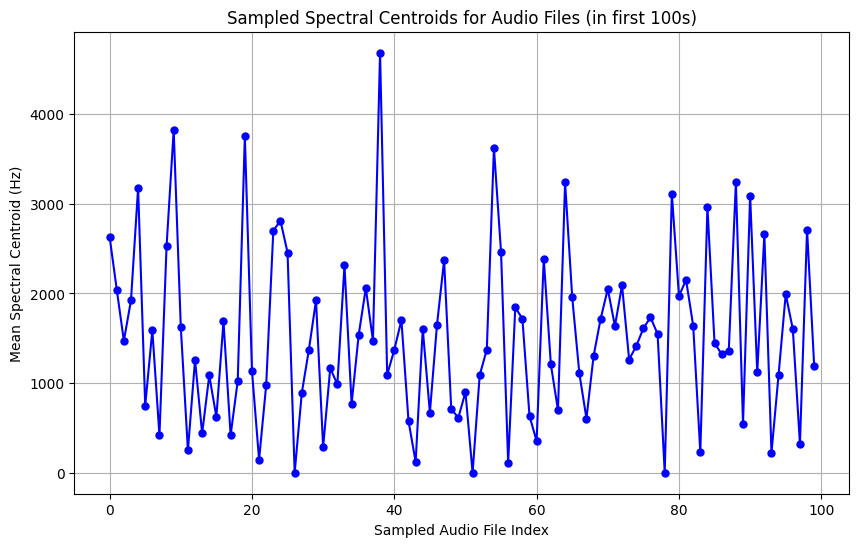

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

try:
    with open(features_pkl_path, 'rb') as f:
        features_list = pickle.load(f)
except FileNotFoundError:
    print(f"File {features_pkl_path} not found.")
    features_list = []

# Extract the spectral centroid values from the features list
centroids_list = []
for feature_data in features_list:
    spectral_centroid_mean = feature_data.get('spectral_centroid_mean')
    if spectral_centroid_mean is not None:
        centroids_list.append(spectral_centroid_mean)

# Check if there are any valid centroids to plot
if not centroids_list:
    print("No valid audio files found or processed.")
else:
    # Convert the list of spectral centroids to a NumPy array
    centroids_array = np.array(centroids_list).reshape(-1, 1)

    # Optional: Reduce the number of data points by sampling
    sample_size = min(100, len(centroids_array))  # Limit to 100 samples
    indices = np.linspace(0, len(centroids_array) - 1, sample_size).astype(int)
    sampled_centroids = centroids_array[indices]

    # Plotting the sampled spectral centroids
    plt.figure(figsize=(10, 6))
    plt.plot(sampled_centroids, marker='o', linestyle='-', color='b', markersize=5)
    plt.title('Sampled Spectral Centroids for Audio Files (in first 100s)')
    plt.xlabel('Sampled Audio File Index')
    plt.ylabel('Mean Spectral Centroid (Hz)')
    plt.grid(True)
    plt.show()


t-SNE'd MFCC Data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

try:
    with open(features_pkl_path, 'rb') as f:
        features_list = pickle.load(f)
except FileNotFoundError:
    print(f"File {features_pkl_path} not found.")
    features_list = []

# 리스트에 3가지 오디오 설명자를 결합한 값을 저장
descriptors_list = []

# 3가지 설명자 키 (필요에 따라 실제 키명으로 수정)
desc_keys = ['mfccs_mean', 'chroma_mean', 'spectral_contrast_mean']

# Extract and combine descriptors for each audio unit
for idx, feature_data in enumerate(features_list):
    combined = []
    valid = True
    for key in desc_keys:
        data = feature_data.get(key)
        if data is None:
            valid = False
            break
        arr = np.array(data)
        # 2D 데이터인 경우 시간축 평균을 취함
        if arr.ndim == 2:
            arr = np.mean(arr, axis=1)
        elif arr.ndim != 1:
            valid = False
            break
        combined.append(arr)
    if valid and len(combined) == len(desc_keys):
        # Concatenate the descriptors along axis 0
        combined_descriptor = np.concatenate(combined)
        descriptors_list.append(combined_descriptor)
    else:
        print(f"Skipping feature_data index {idx}: missing or invalid descriptors.")

if not descriptors_list:
    print("No valid combined descriptor data found.")
else:
    # 모든 feature vector의 길이가 동일한지 확인 후 필터링
    valid_descriptors = []
    valid_indices = []  # 원본 인덱스 저장 리스트
    target_len = None
    for i, vec in enumerate(descriptors_list):
        vec = np.array(vec)
        if vec.size == 0:
            continue
        if target_len is None:
            target_len = vec.shape[0]
        if vec.shape[0] == target_len:
            valid_descriptors.append(vec)
            valid_indices.append(i)
        # else:
        #     print(f"Skipping vector with shape {vec.shape}, expected length {target_len}")

    if not valid_descriptors:
        print("No valid descriptor data with consistent dimensions.")
    else:
        descriptors_array = np.vstack(valid_descriptors)

        # Perform t-SNE to reduce dimensionality to 3D
        tsne = TSNE(n_components=3, random_state=0)
        descriptors_3d = tsne.fit_transform(descriptors_array)

        # 이후 valid_indices와 함께 사용하여 원본 오디오 유닛과 매핑 가능

        # Normalize the 3D coordinates to fit in the range 0 to 1
        min_vals = descriptors_3d.min(axis=0)
        max_vals = descriptors_3d.max(axis=0)
        descriptors_3d_normalized = (descriptors_3d - min_vals) / (max_vals - min_vals)

        # Plot the normalized 3D t-SNE result with RGB coloring
        fig = plt.figure(figsize=(16, 16))
        ax = fig.add_subplot(111, projection='3d')
        sc = ax.scatter(
            descriptors_3d_normalized[:, 0],
            descriptors_3d_normalized[:, 1],
            descriptors_3d_normalized[:, 2],
            c=descriptors_3d_normalized,
            marker='o'
        )

        ax.set_title('Normalized 3D t-SNE of Combined Audio Descriptors with RGB Coloring')
        ax.set_xlabel('Component 1')
        ax.set_ylabel('Component 2')
        ax.set_zlabel('Component 3')
        plt.show()

        # Map the normalized coordinates to RGB values
        colors = descriptors_3d_normalized

        # Determine the grid size for the 2D visualization
        grid_size = int(np.ceil(np.sqrt(len(colors))))
        padded_colors = np.pad(
            colors,
            ((0, grid_size**2 - len(colors)), (0, 0)),
            mode='constant',
            constant_values=1.0
        )
        color_grid = padded_colors.reshape((grid_size, grid_size, 3))

        # Plot the colors as a 2D image
        plt.figure(figsize=(8, 8))
        plt.imshow(color_grid)
        plt.axis('off')
        plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import umap.umap_ as umap
from sklearn.cluster import KMeans

# Constants
SAMPLE_SIZE = int(2**10)  # Sample size for faster processing
CLUSTER_COUNT = 10  # Number of clusters for K-means clustering

def load_features(pickle_path):
    """Load feature data from a pickle file."""
    try:
        with open(pickle_path, 'rb') as f:
            features_list = pickle.load(f)
        return features_list
    except FileNotFoundError:
        print(f"File {pickle_path} not found.")
        return []
    except pickle.UnpicklingError:
        print(f"Error unpickling file {pickle_path}.")
        return []

def extract_mfccs(features_list):
    """Extract MFCC values from the feature list."""
    mfccs_list = []
    
    for feature_data in features_list:
        mfccs_mean = feature_data.get('mfccs_mean')
        
        if mfccs_mean is not None:
            mfccs_mean = np.array(mfccs_mean)
            
            if mfccs_mean.ndim == 1:
                mfccs_list.append(mfccs_mean)
            elif mfccs_mean.ndim == 2:
                mfccs_list.append(np.mean(mfccs_mean, axis=1))
    
    return mfccs_list

def process_mfccs(mfccs_list):
    """Process the MFCC list and perform UMAP."""
    mfccs_array = np.array(mfccs_list)
    
    if len(mfccs_array) > SAMPLE_SIZE:
        mfccs_array = mfccs_array[np.random.choice(mfccs_array.shape[0], SAMPLE_SIZE, replace=False)]
    
    umap_model = umap.UMAP(n_components=3, random_state=0)
    mfccs_3d = umap_model.fit_transform(mfccs_array)
    
    return mfccs_3d

def visualize_mfccs(mfccs_3d, labels=None):
    """Visualize the MFCC data in 3D with clustering."""
    min_vals = mfccs_3d.min(axis=0)
    max_vals = mfccs_3d.max(axis=0)
    
    mfccs_3d_normalized = (mfccs_3d - min_vals) / (max_vals - min_vals)
    
    fig = plt.figure(figsize=(16, 16))
    ax = fig.add_subplot(111, projection='3d')
    
    if labels is not None:
        scatter = ax.scatter(mfccs_3d_normalized[:, 0], mfccs_3d_normalized[:, 1], mfccs_3d_normalized[:, 2], 
                             c=labels, cmap='viridis', marker='o')
        fig.colorbar(scatter, ax=ax)
    else:
        ax.scatter(*mfccs_3d_normalized.T)
    
    ax.set_title('Normalized 3D UMAP of MFCCs with Clustering')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_zlabel('Component 3')
    
    plt.show()

def main():
    pickle_path = 'FSDKaggle2018.audio_train_20240812-151810features_.pkl'
    
    features_list = load_features(pickle_path)
    mfccs_list = extract_mfccs(features_list)
    
    if not mfccs_list:
        print("No valid MFCC data found.")
        return
    
    mfccs_3d = process_mfccs(mfccs_list)
    
    kmeans = KMeans(n_clusters=CLUSTER_COUNT, random_state=0)
    labels = kmeans.fit_predict(mfccs_3d)
    
    visualize_mfccs(mfccs_3d, labels)

if __name__ == '__main__':
    main()


ModuleNotFoundError: No module named 'umap'